### Loan Amount Prediction

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/loan_train.csv")
print("Head (First 5 rows)\n", df.head())
print("Shape\n", df.shape)

Head (First 5 rows)
   Customer ID               Name Gender  Age  Income (USD) Income Stability  \
0     C-36995   Frederica Shealy      F   56       1933.05              Low   
1     C-33999  America Calderone      M   32       4952.91              Low   
2      C-3770      Rosetta Verne      F   65        988.19             High   
3     C-26480         Zoe Chitty      F   65           NaN             High   
4     C-23459       Afton Venema      F   31       2614.77              Low   

  Profession     Type of Employment    Location  Loan Amount Request (USD)  \
0    Working            Sales staff  Semi-Urban                   72809.58   
1    Working                    NaN  Semi-Urban                   46837.47   
2  Pensioner                    NaN  Semi-Urban                   45593.04   
3  Pensioner                    NaN       Rural                   80057.92   
4    Working  High skill tech staff  Semi-Urban                  113858.89   

   ...  Credit Score No. of Default

In [33]:
print("Info \n", df.info())
print("Describe \n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

In [34]:
print(df.isnull().sum())

Customer ID                       0
Name                              0
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property ID                       0
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64


#### Exploratory Data Analysis

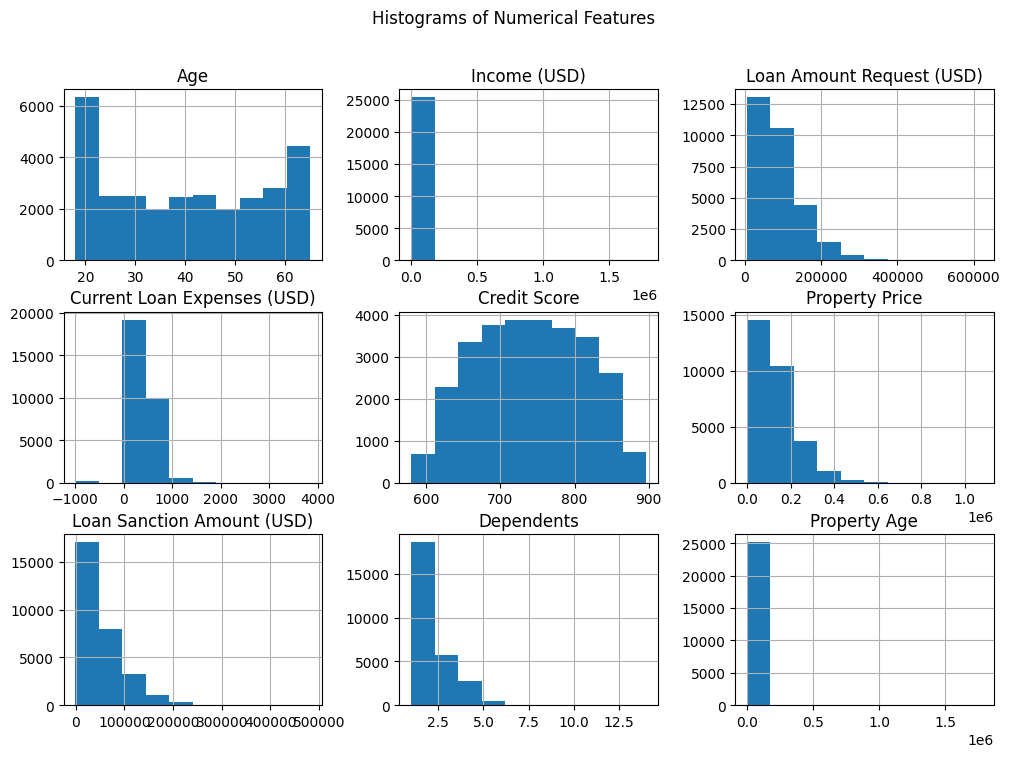

In [35]:
numcols = ['Age', 'Income (USD)', 'Loan Amount Request (USD)',
'Current Loan Expenses (USD)', 'Credit Score',
'Property Price', 'Loan Sanction Amount (USD)','Dependents','Property Age']

df[numcols].hist(figsize=(12,8))
plt.suptitle("Histograms of Numerical Features")
plt.show()

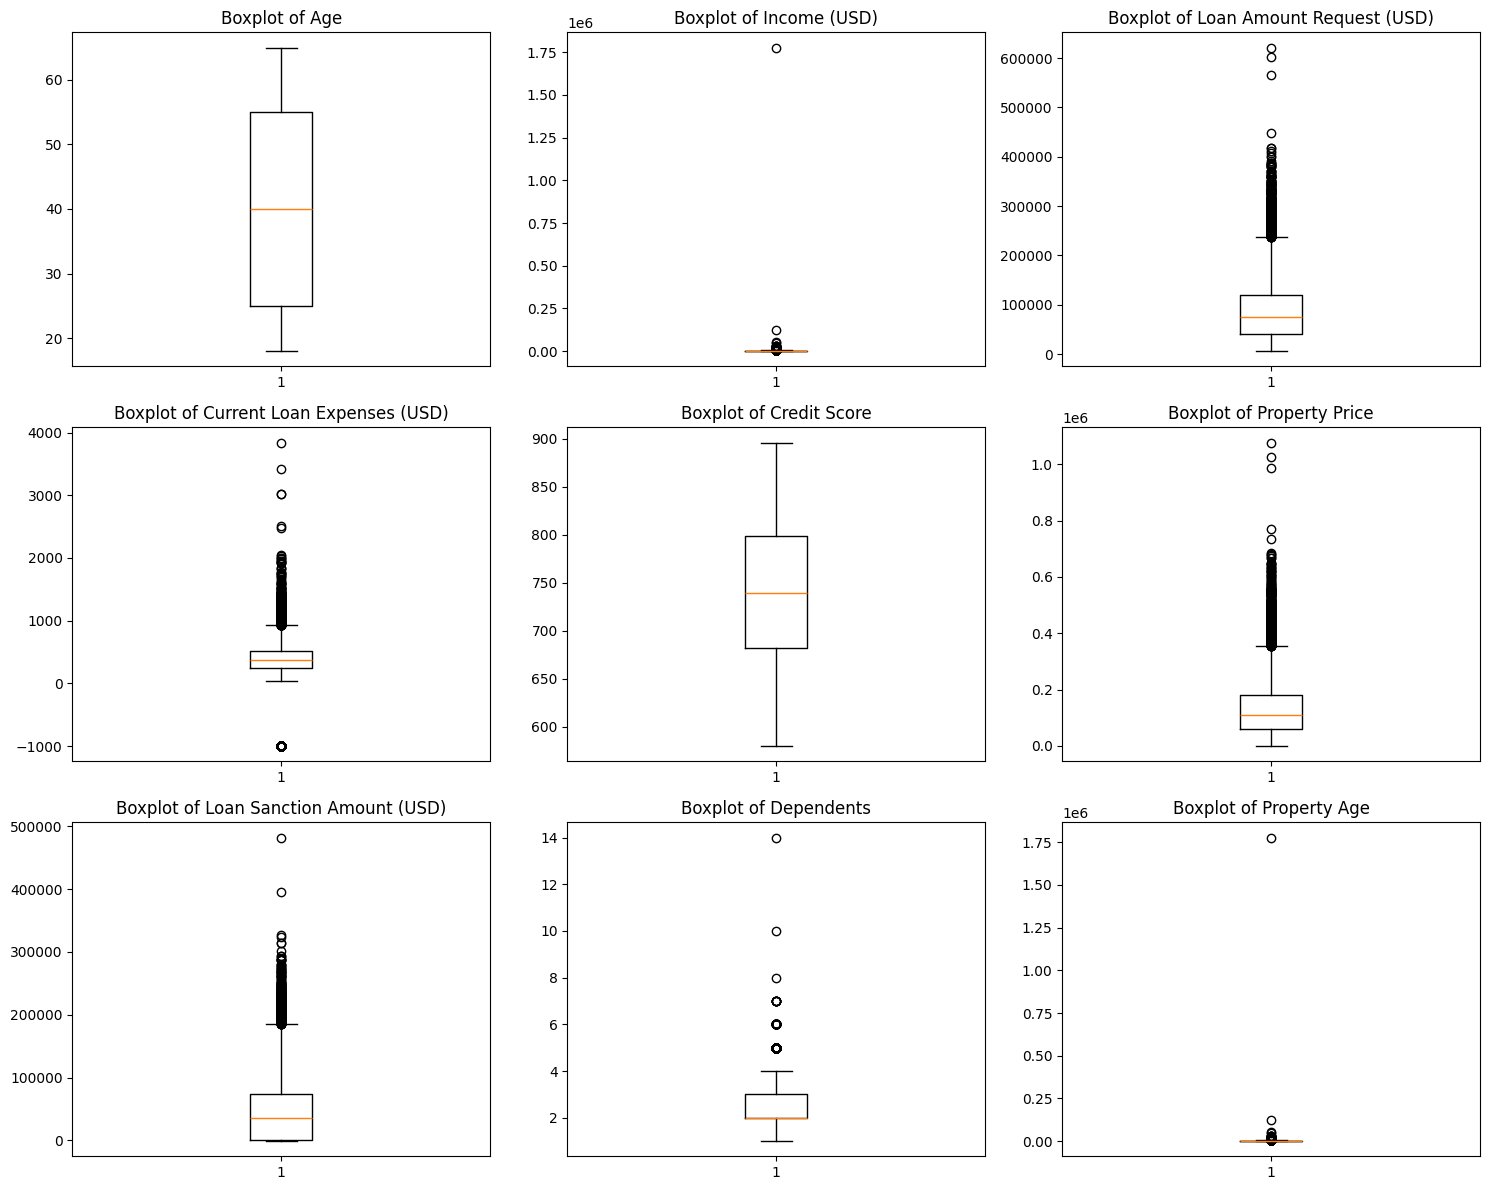

In [36]:
import matplotlib.pyplot as plt

num_cols = [
    'Age', 'Income (USD)', 'Loan Amount Request (USD)',
    'Current Loan Expenses (USD)', 'Credit Score',
    'Property Price', 'Loan Sanction Amount (USD)',
    'Dependents','Property Age'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # 3x3 grid
axes = axes.flatten()  # flatten to easily loop

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Count')

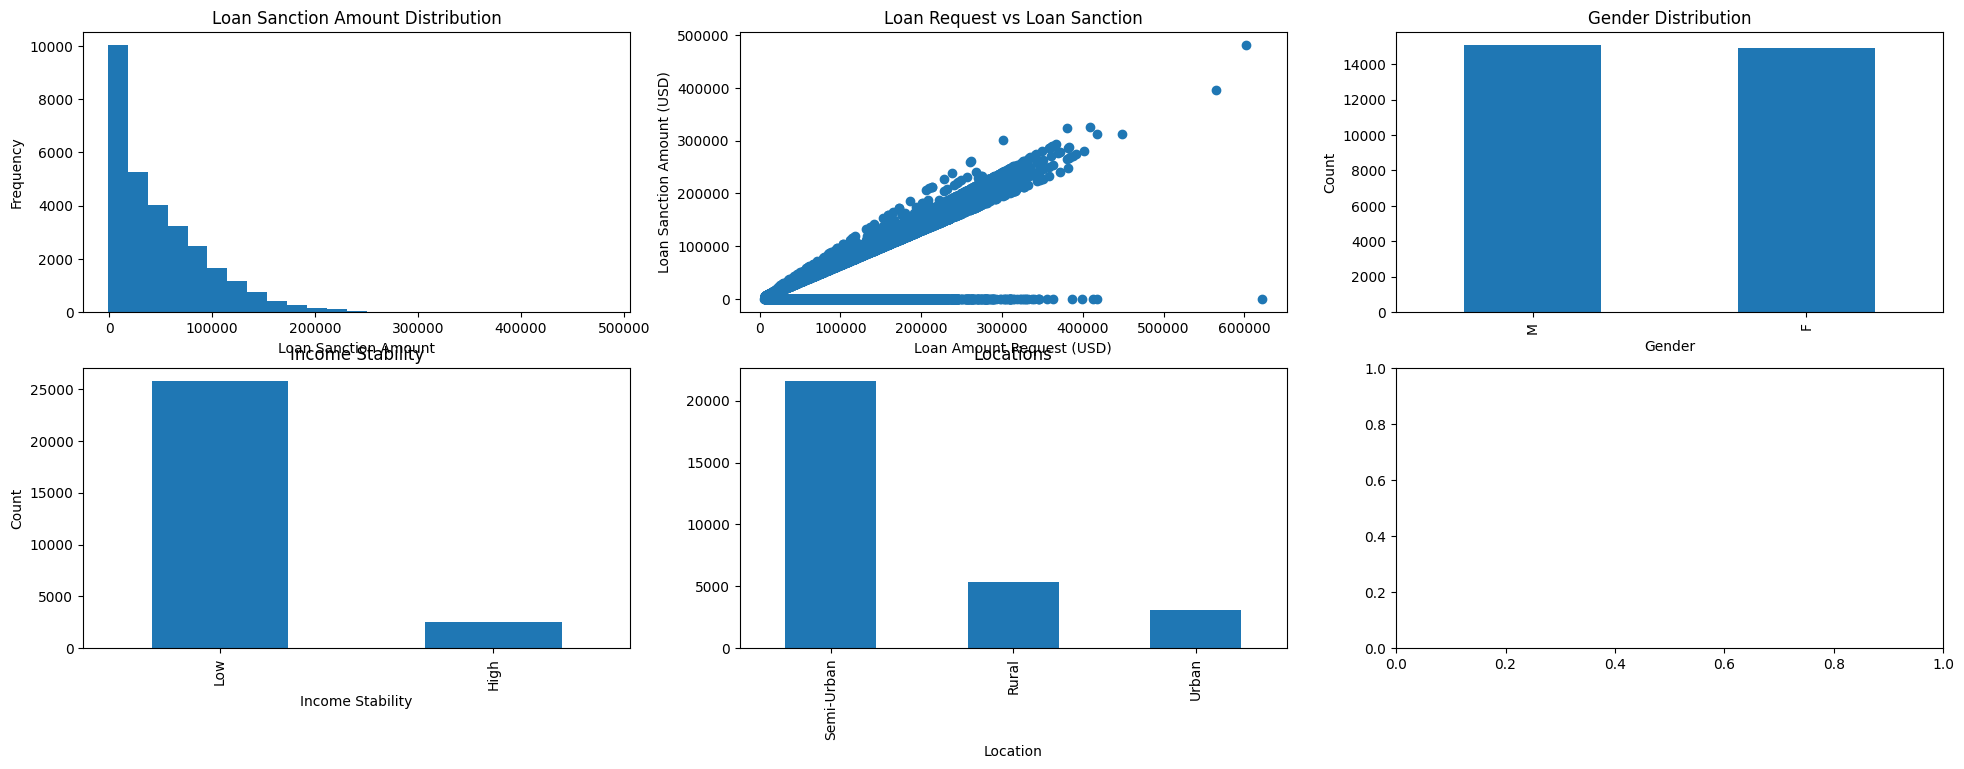

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(24, 8))
axes = axes.flatten()
# Histogram
axes[0].hist(df["Loan Sanction Amount (USD)"], bins=25)
axes[0].set_title("Loan Sanction Amount Distribution")
axes[0].set_xlabel("Loan Sanction Amount")
axes[0].set_ylabel("Frequency")

axes[1].scatter(df["Loan Amount Request (USD)"], df["Loan Sanction Amount (USD)"])
axes[1].set_xlabel("Loan Amount Request (USD)")
axes[1].set_ylabel("Loan Sanction Amount (USD)")
axes[1].set_title("Loan Request vs Loan Sanction")

df["Gender"].value_counts().plot(kind = 'bar', ax = axes[2])
axes[2].set_title("Gender Distribution")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Count")

df["Income Stability"].value_counts().plot(kind = 'bar', ax = axes[3])
axes[3].set_title("Income Stability")
axes[3].set_xlabel("Income Stability")
axes[3].set_ylabel("Count")

df["Location"].value_counts().plot(kind = 'bar', ax = axes[4])
axes[4].set_title("Locations")
axes[3].set_ylabel("Count")

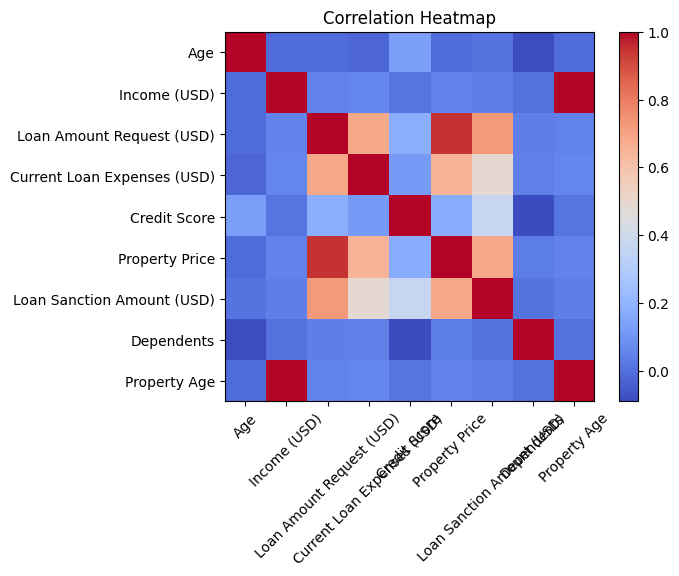

In [38]:
corr = df[numcols].corr()
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

### Iris

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('datasets/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [40]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


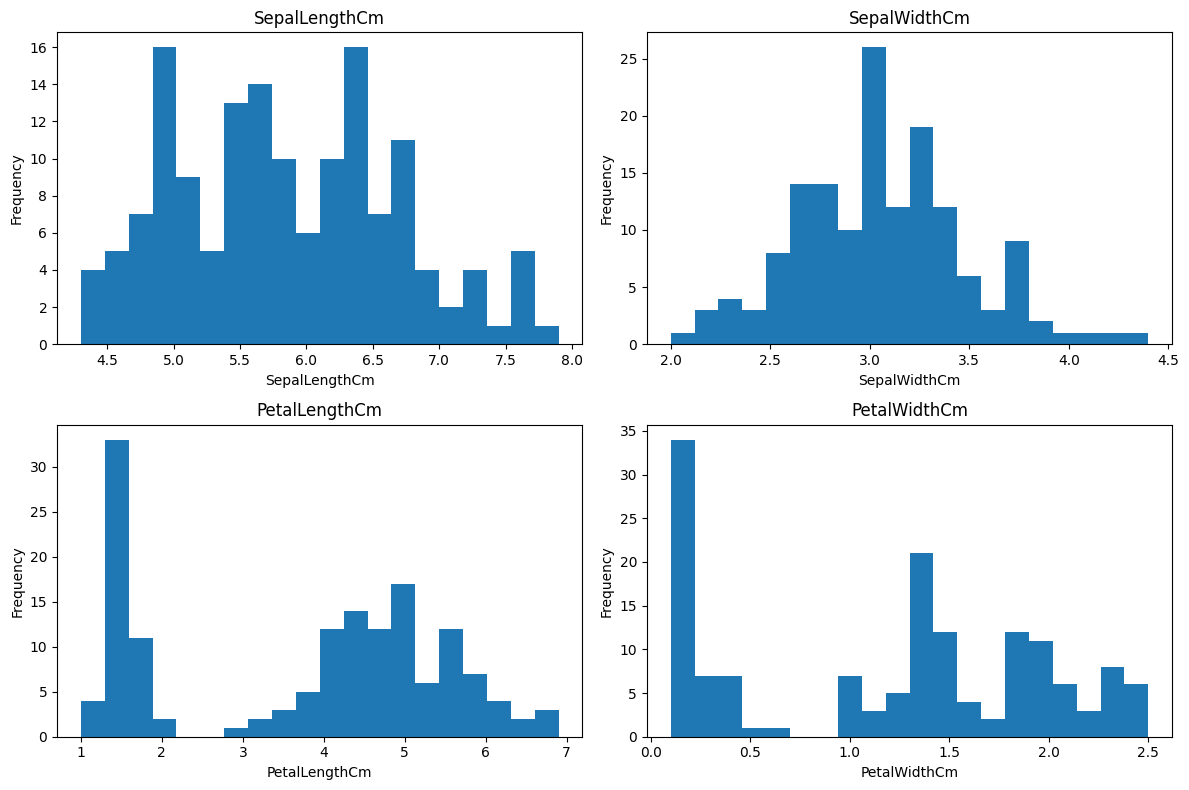

In [41]:
features = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]

plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

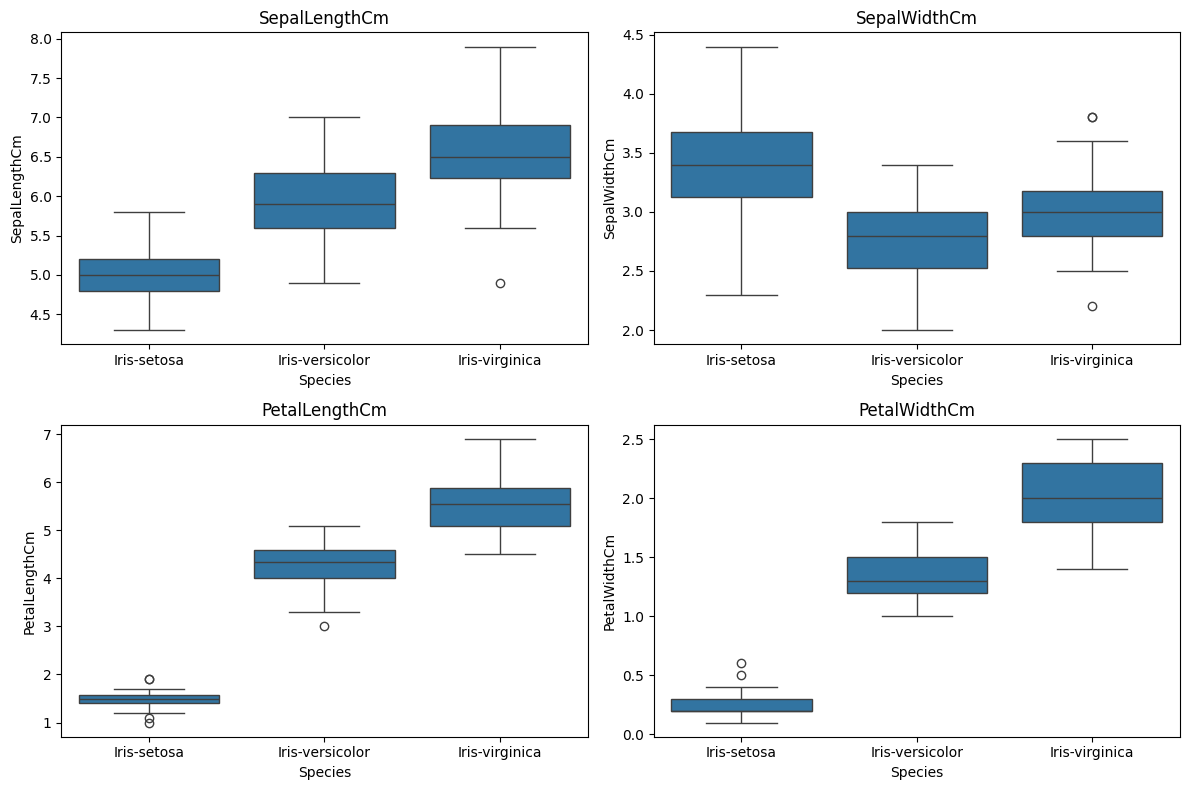

In [42]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Species', y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()


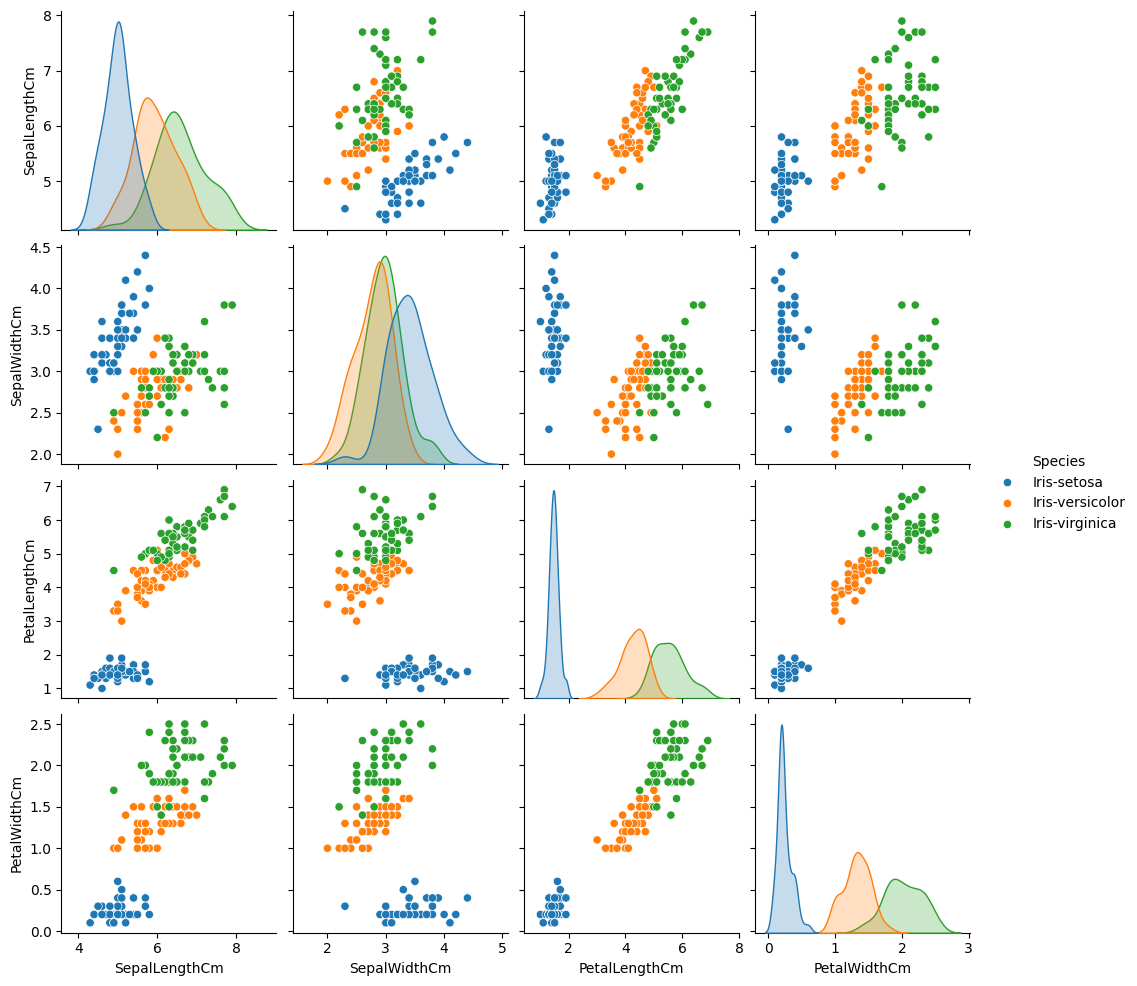

In [43]:
sns.pairplot(df.drop('Id', axis = 1), hue='Species')
plt.show()

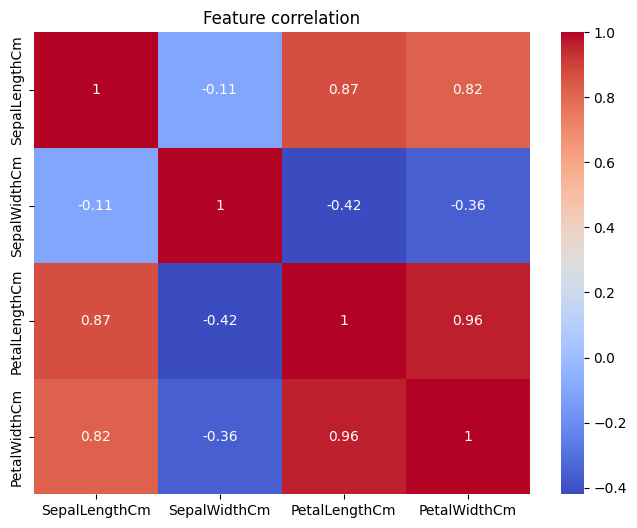

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(['Species', 'Id'], axis=1).corr(),
            annot=True, cmap='coolwarm')
plt.title("Feature correlation")
plt.show()

### Hand Written Character Recognition

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

df = pd.read_csv("datasets/english.csv")

In [46]:
print("Shape:", df.shape)
print("Info\n",df.info())
print("Head\n",df.head())

print(df.isnull().sum())

Shape: (3410, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   3410 non-null   object
 1   label   3410 non-null   object
dtypes: object(2)
memory usage: 53.4+ KB
Info
 None
Head
                 image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0
image    0
label    0
dtype: int64


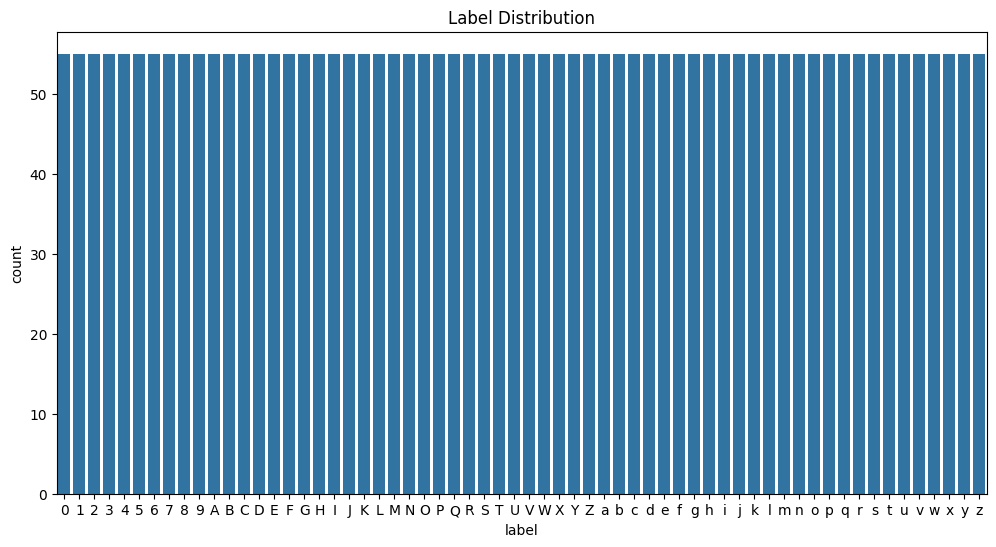

In [47]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Label Distribution")
plt.show()

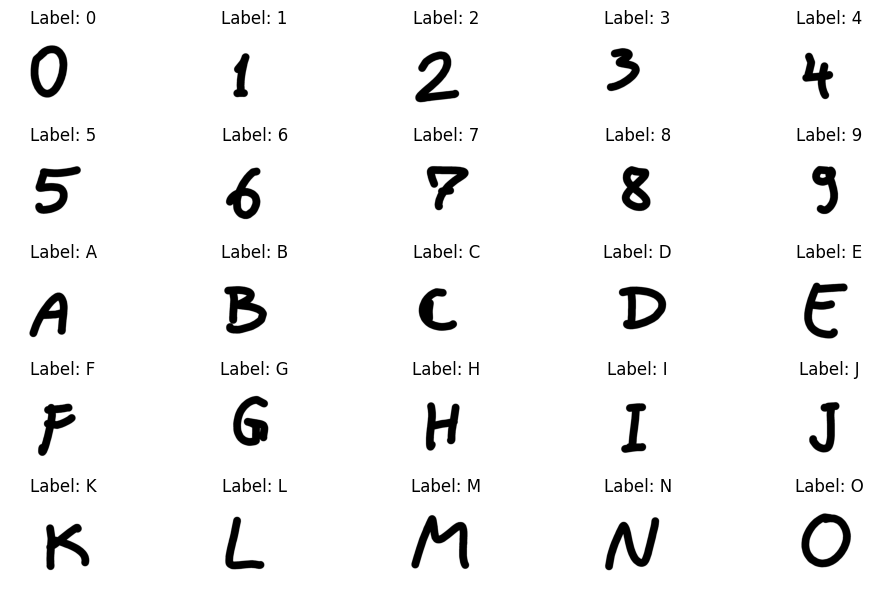

In [48]:
from PIL import Image

plt.figure(figsize=(10, 6))

unique = df.groupby('label').first().reset_index().head(25)

for i, row in unique.iterrows():
    img_path = row['image']
    label = row['label']

    img = Image.open(f"datasets/{img_path}")

    plt.subplot(5, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


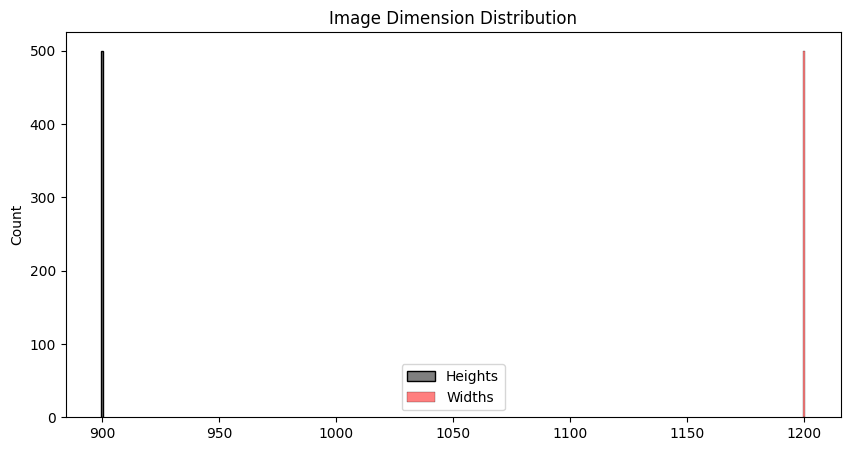

In [49]:
from PIL import Image

heights = []
widths = []

for img_path in df['image'][:500]:   
    img = Image.open(f"datasets/{img_path}")
    w, h = img.size
    widths.append(w)
    heights.append(h)


plt.figure(figsize=(10,5))
sns.histplot(heights, kde=True, color="black", label="Heights")
sns.histplot(widths, kde=True, color="red", label="Widths")
plt.legend()
plt.title("Image Dimension Distribution")
plt.show()

In [50]:
import pandas as pd

df = pd.read_csv("datasets/diabetes.csv")

In [51]:
print("Shape:", df.shape)
print("Info\n", df.info())
print("Head\n", df.head())

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Info
 None
Head
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0 

In [52]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [53]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

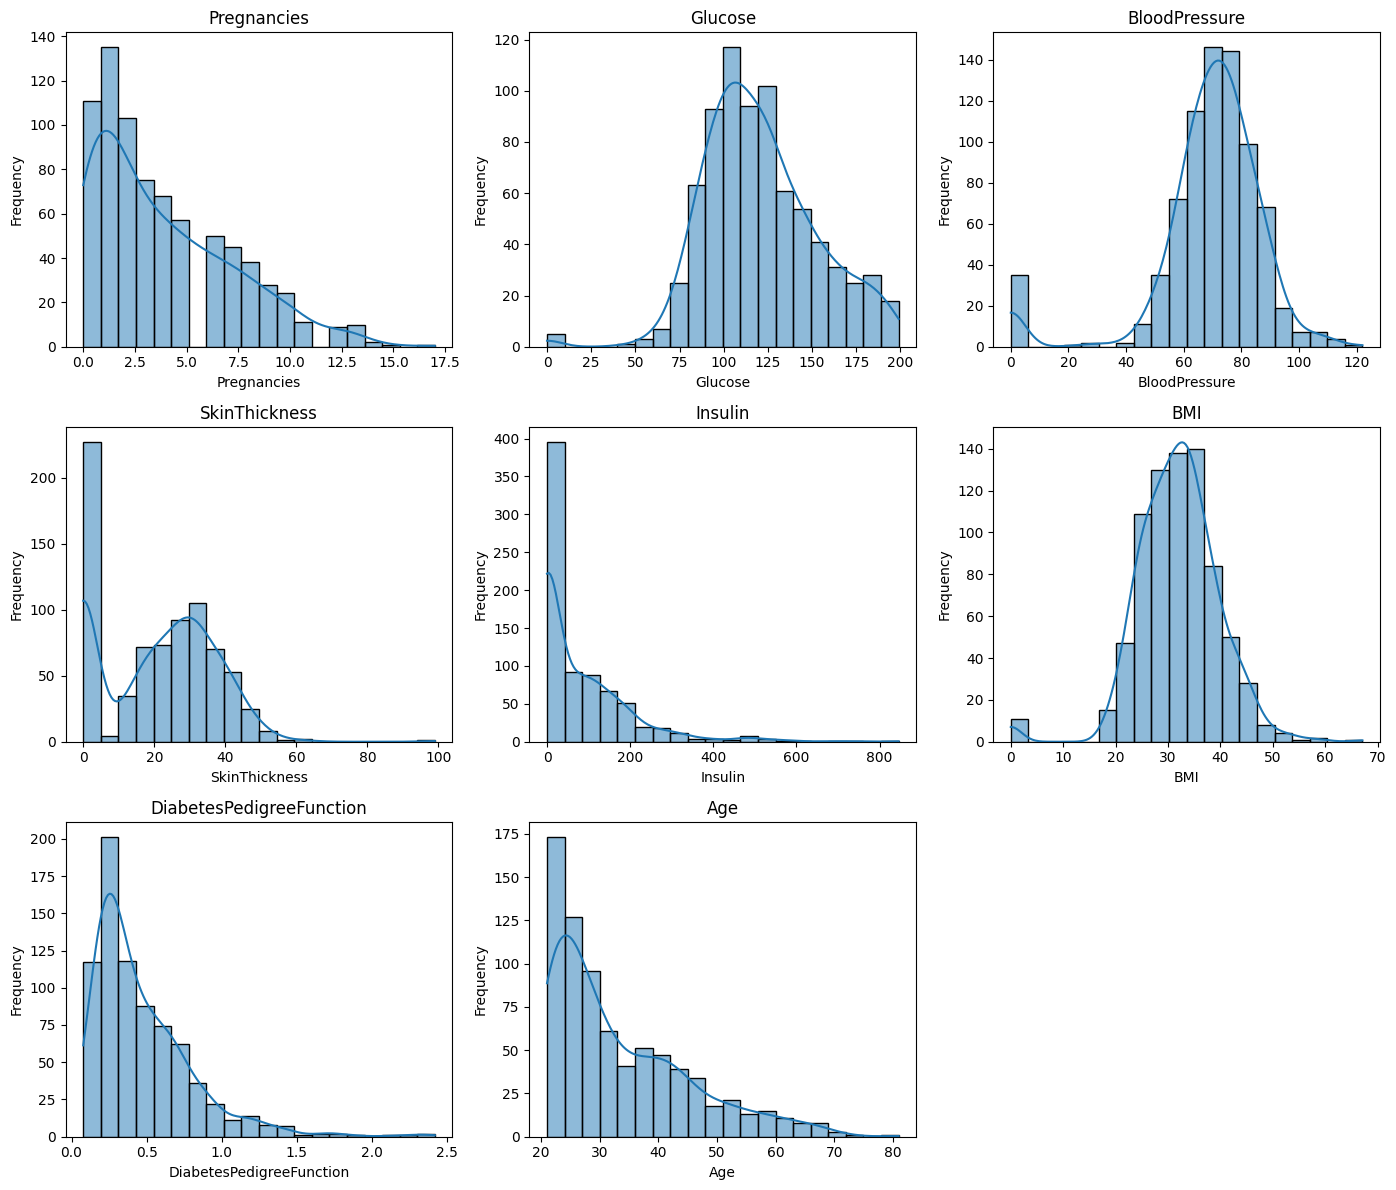

In [54]:
features = df.drop('Outcome', axis=1).columns

plt.figure(figsize=(14, 12))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout() 
plt.show()


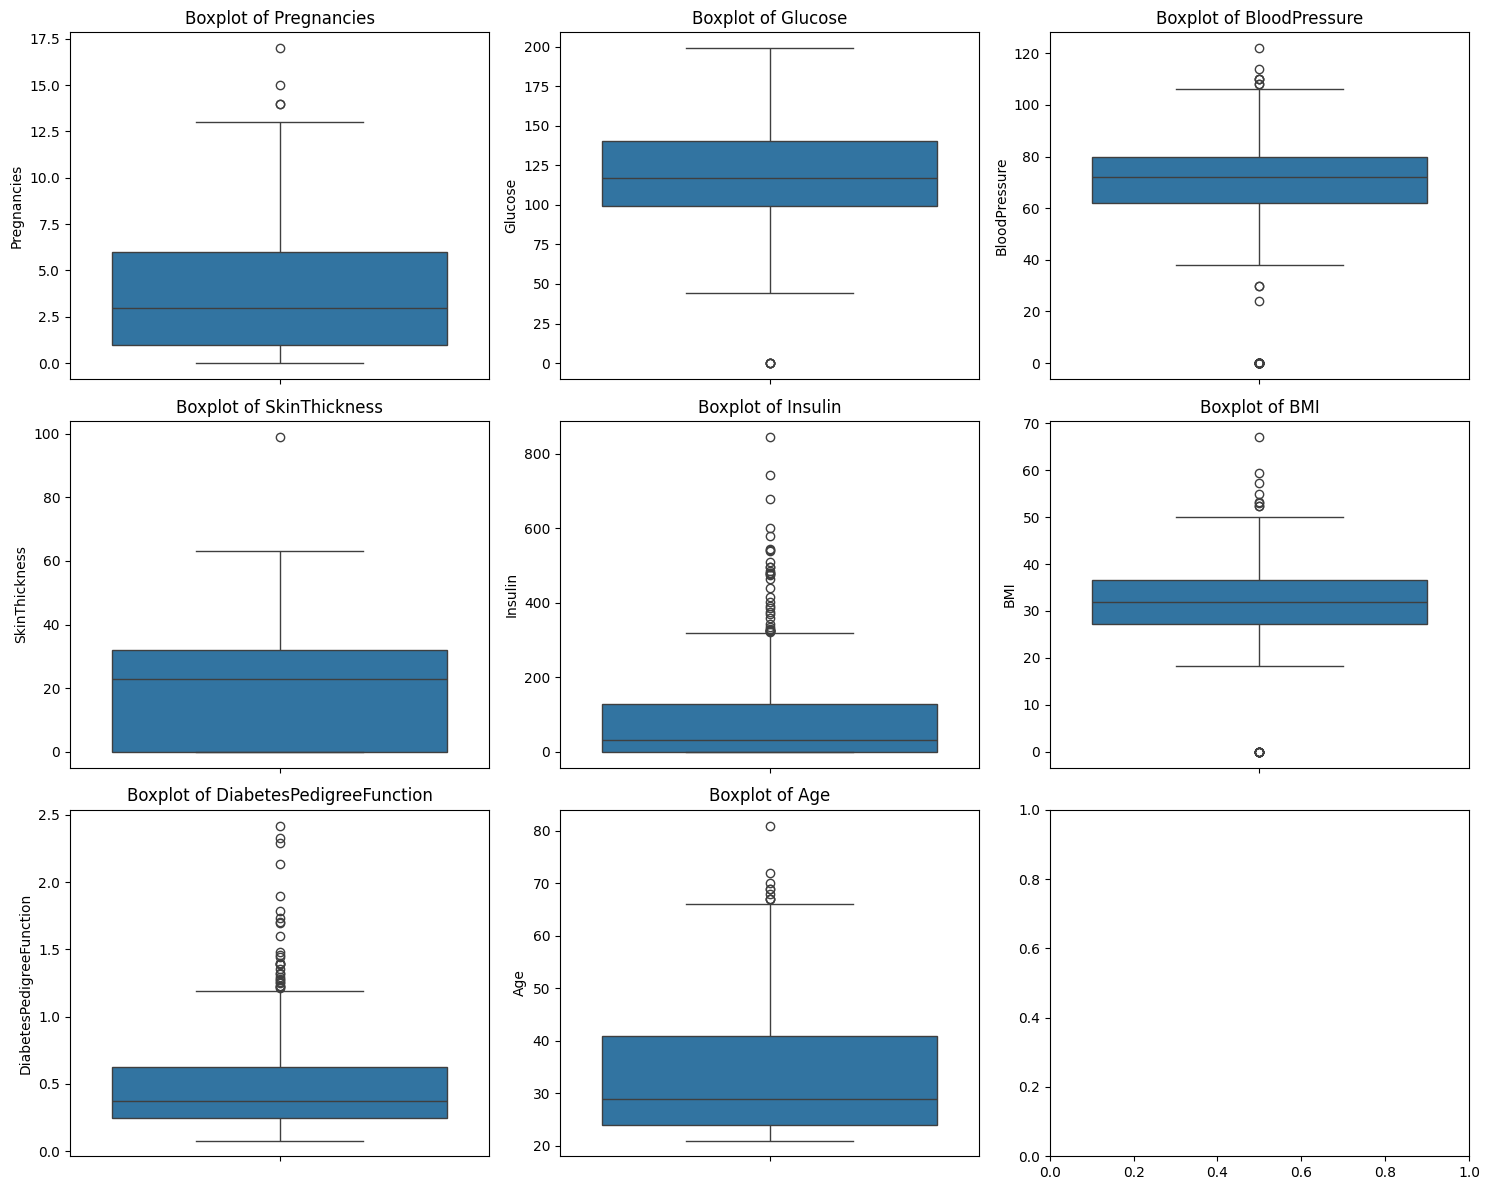

In [55]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')


plt.tight_layout()
plt.show()

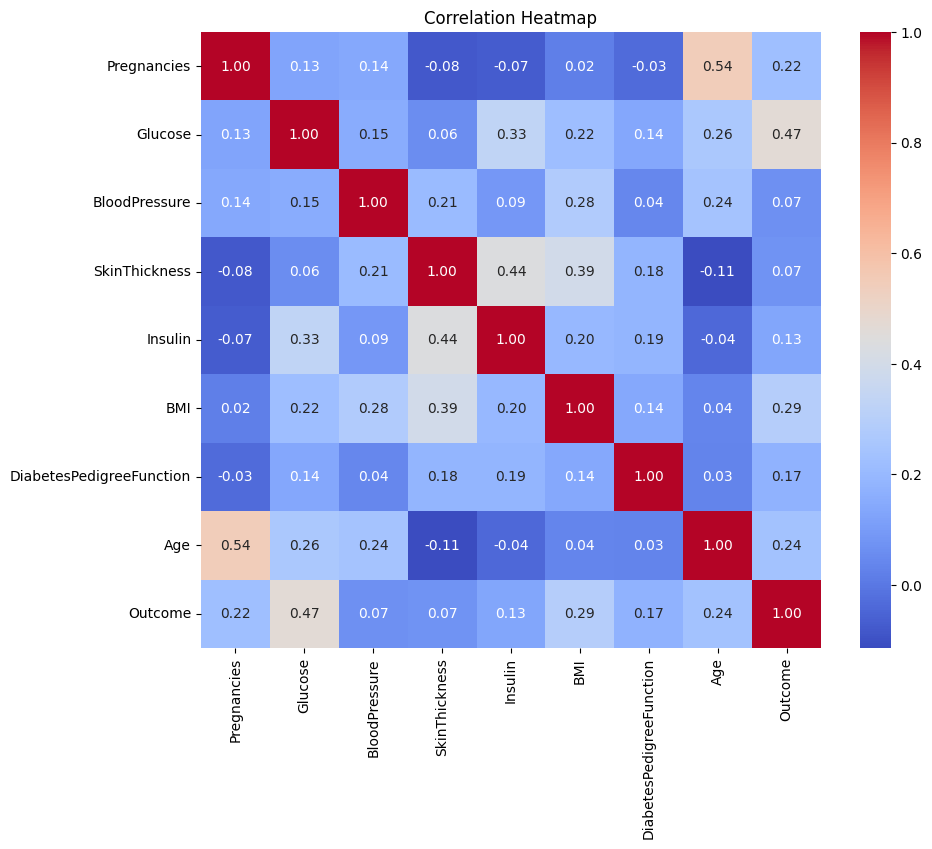

In [56]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Email Classification

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/email.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [58]:
print("Info\n", df.info())
print("Describe \n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
Info
 None
Describe 
        Category                 Message
count      5572                    5572
unique        2                    5157
top         ham  Sorry, I'll call later
freq       4825                      30


In [59]:
print("Null Values\n", df.isnull().sum())
print("Counts of spam and Ham \n", df['Category'].value_counts())

Null Values
 Category    0
Message     0
dtype: int64
Counts of spam and Ham 
 Category
ham     4825
spam     747
Name: count, dtype: int64


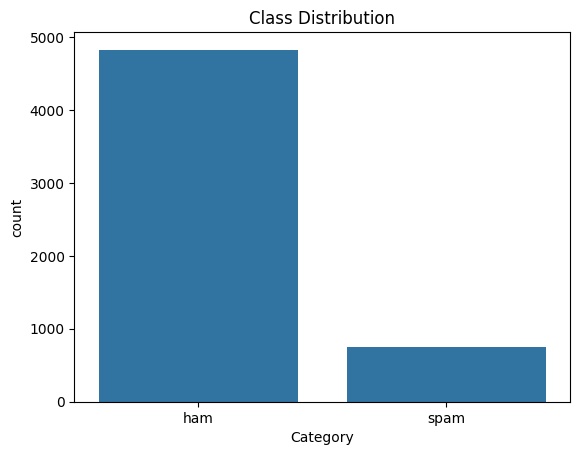

In [60]:
sns.countplot(x='Category', data=df)
plt.title("Class Distribution")
plt.show()

In [61]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['clean_text'] = df['Message'].apply(clean_text)

In [62]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_text'].apply(len)

In [63]:
df.head()

,Category,Message,clean_text,word_count,char_count
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,20,102
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,6,23
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...,25,124
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,11,43
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,13,59


In [64]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
common_words = Counter(all_words).most_common(20)
common_words

[('i', 2249),
 ('to', 2248),
 ('you', 2128),
 ('a', 1448),
 ('the', 1331),
 ('u', 1154),
 ('and', 971),
 ('is', 892),
 ('in', 889),
 ('me', 791),
 ('my', 759),
 ('for', 711),
 ('your', 677),
 ('it', 622),
 ('of', 622),
 ('call', 578),
 ('have', 573),
 ('on', 536),
 ('that', 514),
 ('are', 490)]

In [65]:
spam_words = " ".join(df[df['Category']=="spam"]['clean_text']).split()
ham_words = " ".join(df[df['Category']=="ham"]['clean_text']).split()

print("Spam words most common \n\n", Counter(spam_words).most_common(15))
print("\nNot Spam common words \n", Counter(ham_words).most_common(15))

Spam words most common 

 [('to', 686), ('a', 380), ('call', 347), ('you', 287), ('your', 263), ('free', 219), ('for', 204), ('the', 201), ('now', 190), ('or', 188), ('is', 157), ('u', 153), ('txt', 151), ('on', 145), ('ur', 144)]

Not Spam common words 
 [('i', 2195), ('you', 1841), ('to', 1562), ('the', 1130), ('a', 1068), ('u', 1001), ('and', 849), ('in', 817), ('me', 761), ('my', 748), ('is', 735), ('it', 594), ('of', 525), ('for', 507), ('that', 488)]
